## Data cleaning pipeline for the CIFAR-10 Dataset

The dataset is locally sourced. Original dataset includes the set of images and a .csv file containing the labels. Data preparation includes labeling the images using the given .csv file and then processing the image data itself to prepare it for model training.

In [ ]:
# Import libraries for data processing
import pandas as pd
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

2025-12-04 12:39:53.265791: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/hansen/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Load labels data
csv_path = "cifar-10/trainLabels.csv"
df = pd.read_csv(csv_path)

df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [3]:
# Labeling the image data in the dataframe
img_dir = "cifar-10/train/"

# Add filepath column to label images via the ID column
df["filepath"] = df["id"].apply(lambda x: os.path.join(img_dir, f"{x}.png"))

label_map = {'frog':0, 'truck':1, 'deer':2, 'automobile':3, 'bird':4, 
             'horse':5, 'ship':6, 'cat':7, 'dog':8, 'airplane':9}
df["label_id"] = df["label"].map(label_map)


# Remove missing images from the dataframe: handle null data
df = df[df["filepath"].apply(lambda p: os.path.exists(p))]

df.head()

,id,label,filepath,label_id
0,1,frog,cifar-10/train/1.png,0
1,2,truck,cifar-10/train/2.png,1
2,3,truck,cifar-10/train/3.png,1
3,4,deer,cifar-10/train/4.png,2
4,5,automobile,cifar-10/train/5.png,3


In [4]:
# Load image data and label it
filepaths = df["filepath"].values
labels = df["label_id"].values.astype("int64")

dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

In [ ]:
# Cleaning function
# Proposed image size: 32x32 as that is the standard size for this dataset
IMG_SIZE = 32


def load_and_clean_image(path, label):
    # Identify erroneous images, return black placeholders for erroneous images
    def safe_decode(p):
        try:
            img = tf.io.read_file(p) # load file from path
            img = tf.image.decode_png(img, channels=3) # decode to tensor 
            return img.numpy() # return tensor as an array
        except Exception:
            # Return a black placeholder
            return np.zeros((32, 32, 3), dtype=np.uint8)

    # TF wrapper to allow try/except
    # Instead of crashing on erroneous data, it will return the placeholder
    img = tf.py_function(func=safe_decode, inp=[path], Tout=tf.uint8)
    
    # Initialize the image resolution after loading it
    img.set_shape([None, None, 3]) 

    # Convert to floats for image processing
    img = tf.image.convert_image_dtype(img, tf.float32) 

    # Remove unusual characters and occulusions by detecting outliers in pixel values
    mean = tf.reduce_mean(img)
    std = tf.math.reduce_std(img)
    z = (img - mean) / (std + 1e-6) # z-score to use as a baseline for outlier detection
    img = tf.where(tf.abs(z) > 3.0, mean, img)

    # Basic noise reduction
    # Increase brightness and contrast slightly to make objects more distinct
    img = tf.image.adjust_brightness(img, 0.01)
    img = tf.image.adjust_contrast(img, 1.05)

    # Gaussian blur removal (sharpening filter) 
    # Create a commonly used filter for sharpening images
    kernel = tf.constant([[0,-1,0],[-1,5,-1],[0,-1,0]], tf.float32)
    kernel = tf.reshape(kernel, [3,3,1,1])
    kernel = tf.tile(kernel, [1,1,3,1])
    # Specify batch size (none), kernel, strides, padding
    img = tf.nn.depthwise_conv2d(img[None], kernel, strides=[1,1,1,1], padding='SAME')[0]

    # Standardize the image size
    # Pad image
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    # Clip to valid pixel range (Normalizes the values)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, label

In [ ]:
# Data Augmentation: For the purpose of visualization and example. 
# For the actual model, augmentation will be done in the model training environment
def augment(img, label):
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_saturation(img, 0.5, 1.5)
    return img, label

In [7]:
# Compare raw, cleaned, and augmented images
def show_all_stages(path, label):
    raw = tf.io.read_file(path)
    raw = tf.image.decode_png(raw, channels=3)

    cleaned, _ = load_and_clean_image(path, label)
    augmented, _ = augment(cleaned, label)

    plt.figure(figsize=(12,3))

    plt.subplot(1,3,1)
    plt.imshow(raw.numpy())
    plt.title(f"Raw {label}")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(cleaned.numpy())
    plt.title(f"Clean {label}")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(augmented.numpy())
    plt.title(f"Augment {label}")
    plt.axis("off")

    plt.show()


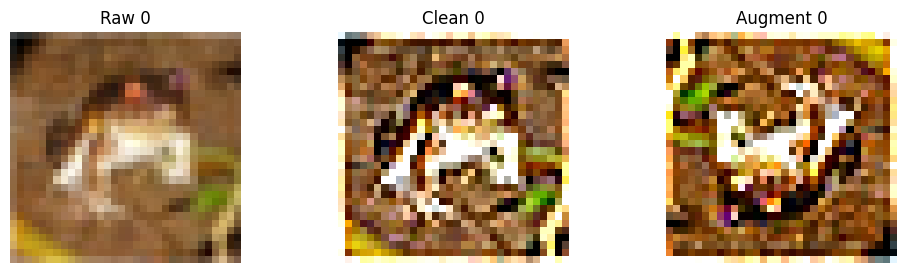

2025-12-04 12:40:18.700171: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# Test and validate proessing steps
for image, label in dataset.take(1):
    show_all_stages(image, label)

In [ ]:
# Apply processing steps onto the whole dataset
dataset = dataset.map(load_and_clean_image, num_parallel_calls=tf.data.AUTOTUNE)

# Remove any failed images (zero arrays)
dataset = dataset.filter(lambda img, label: tf.reduce_mean(img) > 0.0)

In [10]:
# Specify batches and create a train/val/test split
# Using a train:val:test ratio of 70%:15%:15%
train_size = int(0.7 * len(df))
val_size   = int(0.15 * len(df))
test_size  = len(df) - train_size - val_size

train_ds = dataset.take(train_size)
val_ds   = dataset.skip(train_size).take(val_size)
test_ds  = dataset.skip(train_size + val_size)

BATCH_SIZE = 32

train_ds = train_ds.shuffle(50000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Saving the processed datasets
# Serialize each image and label together
def serialize(img, label):
    # Convert image to raw bytes
    img_raw = tf.io.serialize_tensor(img)
    
    feature = {
        "image": tf.train.Feature(bytes_list=tf.train.BytesList(value=[img_raw.numpy()])),
        "label": tf.train.Feature(int64_list=tf.train.Int64List(value=[int(label)])),
    }
    
    sample = tf.train.Example(features=tf.train.Features(feature=feature))
    return sample.SerializeToString()


def save_file(dataset, filename):
    options = tf.io.TFRecordOptions(compression_type="GZIP")
    
    with tf.io.TFRecordWriter(filename, options=options) as writer:
        for batch_imgs, batch_labels in dataset:
            for img, lbl in zip(batch_imgs, batch_labels):
                sample = serialize(img, lbl)
                writer.write(sample)
    
    print(f"Saved TFRecord: {filename}")

save_file(train_ds, "train.tfrecord.gz")
save_file(val_ds,   "val.tfrecord.gz")
save_file(test_ds,  "test.tfrecord.gz")


2025-12-04 12:40:42.705217: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:10: Filling up shuffle buffer (this may take a while): 28343 of 50000
2025-12-04 12:40:45.416603: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2025-12-04 12:41:27.581850: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Saved TFRecord: train.tfrecord.gz


2025-12-04 12:41:51.259920: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Saved TFRecord: val.tfrecord.gz
Saved TFRecord: test.tfrecord.gz


2025-12-04 12:42:19.360157: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
